<a href="https://colab.research.google.com/github/bullseye000/stock_analyzer/blob/main/Stock_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install yfinance pandas numpy matplotlib scikit-learn


In [54]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [55]:
stock_name = input("Enter Stock (Example: TATAMOTORS.NS): ")

Enter Stock (Example: TATAMOTORS.NS): sbin.ns


In [56]:
import yfinance as yf
import pandas as pd

# Create ticker object
stock = yf.Ticker(stock_name)

# 📊 Get historical data (for ML)
raw_historical_data = stock.history(start="2020-01-01", end="2025-01-01")

# Check if raw historical data is empty
if raw_historical_data.empty:
    print(f"Error: No historical data found for '{stock_name}'. Please check the stock symbol for correctness (e.g., 'GOOGL', 'TATAMOTORS.NS').")
    # Initialize 'data' as an empty DataFrame with 'Close' column to prevent subsequent errors
    data = pd.DataFrame(columns=['Close'])
    current_price = None # No current price if no data
else:
    # Keep only Close column
    data = raw_historical_data[['Close']].copy()

    # Remove missing values
    data = data.dropna()

    # 📍 Get latest (real-time-ish) price
    daily_history = stock.history(period="1d")
    if not daily_history.empty:
        current_price = daily_history['Close'].iloc[-1]
    else:
        print(f"Warning: Could not retrieve 1-day history for '{stock_name}'. Attempting to use the last available close from historical data if available.")
        if not data.empty:
            current_price = data['Close'].iloc[-1]
        else:
            current_price = None # Still no current price if even long historical data is empty after dropna

# Print current price if available
if current_price is not None:
    print("Current Price:", current_price)
else:
    print("Current Price: Not available due to data fetching issues.")

# Show last 5 rows if data is not empty
print("\nLast 5 rows:")
if not data.empty:
    print(data.tail())
else:
    print("No historical data to show.")

Current Price: 1048.9000244140625

Last 5 rows:
                                Close
Date                                 
2024-12-24 00:00:00+05:30  796.065369
2024-12-26 00:00:00+05:30  796.457520
2024-12-27 00:00:00+05:30  783.909485
2024-12-30 00:00:00+05:30  772.782837
2024-12-31 00:00:00+05:30  779.301941


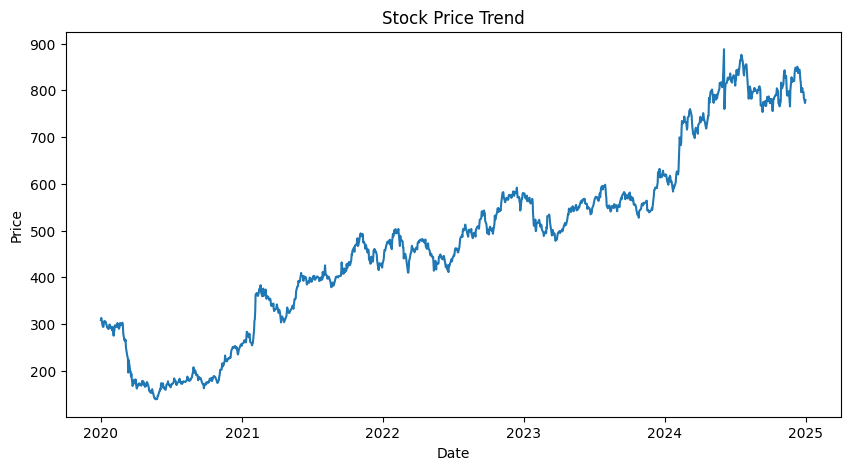

In [57]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [58]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [59]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

In [60]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [61]:
model = LinearRegression()

X_train_reshaped = X_train.reshape(len(X_train), -1)
model.fit(X_train_reshaped, y_train)

LinearRegression()

In [62]:
X_test_reshaped = X_test.reshape(len(X_test), -1)

predictions = model.predict(X_test_reshaped)
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

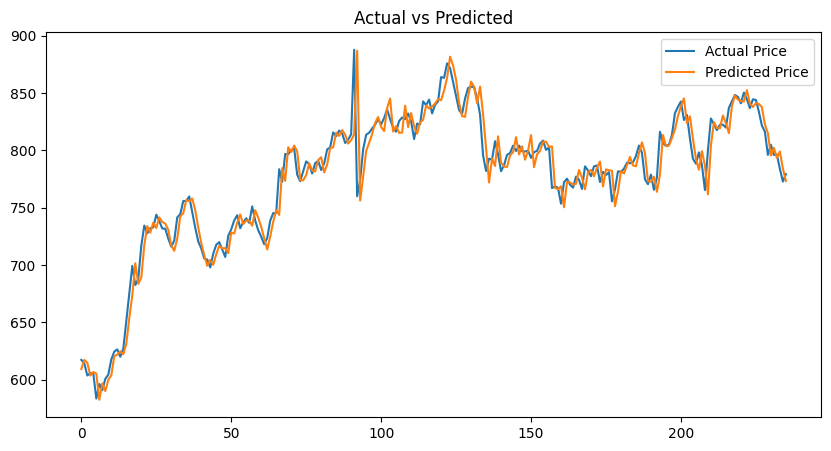

In [63]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [64]:
stock = yf.Ticker(stock_name)
current_price = stock.history(period="1d")['Close'][0]

print("Current Price:", current_price)

Current Price: 1048.9000244140625


/tmp/ipykernel_194/964105403.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_price = stock.history(period="1d")['Close'][0]


In [65]:
predicted_price = predictions[-1][0]

print("Predicted Price:", predicted_price)

Predicted Price: 773.2861772548267


In [66]:
if current_price > predicted_price:
    status = "Overpriced"
else:
    status = "Underpriced"

print("Status:", status)

Status: Overpriced


In [67]:
if predicted_price > current_price:
    trend = "UPWARD 📈"
else:
    trend = "DOWNWARD 📉"

print("Trend:", trend)

Trend: DOWNWARD 📉


In [68]:
percent = ((predicted_price - current_price) / current_price) * 100

print("Expected Change: {:.2f}%".format(percent))

Expected Change: -26.28%


In [69]:
buy_price = predicted_price * 0.95
sell_price = predicted_price * 1.05

print("Buy Below:", round(buy_price,2))
print("Sell Above:", round(sell_price,2))

Buy Below: 734.62
Sell Above: 811.95


In [70]:
print("\n📊 STOCK ANALYSIS RESULT\n")

print("Stock:", stock_name)
print("Current Price: ₹", round(current_price,2))
print("Predicted Price: ₹", round(predicted_price,2))

print("Status:", status)
print("Trend:", trend)

print("Expected Growth: {:.2f}%".format(percent))

print("\nRecommendation:")
print("Buy Below ₹", round(buy_price,2))
print("Sell Above ₹", round(sell_price,2))


📊 STOCK ANALYSIS RESULT

Stock: sbin.ns
Current Price: ₹ 1048.9
Predicted Price: ₹ 773.29
Status: Overpriced
Trend: DOWNWARD 📉
Expected Growth: -26.28%

Recommendation:
Buy Below ₹ 734.62
Sell Above ₹ 811.95


In [71]:
pip install streamlit yfinance scikit-learn matplotlib


In [84]:
import streamlit as st
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Title
st.title("📈 AI Stock Price Analysis App")

# Input
stock_name = st.text_input("Enter Stock Name (Example: TATAMOTORS.NS)")

if st.button("Analyze Stock"):

    # Create ticker object
    stock = yf.Ticker(stock_name)

    # 📍 REAL-TIME PRICE
    try:
        current_price = stock.history(period="1d")['Close'][-1]
    except:
        st.error("❌ Unable to fetch stock data. Check stock name.")
        st.stop()

    # 📊 Historical data
    data = stock.history(start="2020-01-01", end="2025-01-01")

    if data.empty:
        st.error("❌ Invalid stock name")
    else:
        data = data[['Close']].dropna()

        # 📊 Moving Averages
        data['MA50'] = data['Close'].rolling(window=50).mean()
        data['MA200'] = data['Close'].rolling(window=200).mean()

        ma50 = data['MA50'].iloc[-1]
        ma200 = data['MA200'].iloc[-1]

        # 📈 Graph
        st.subheader("📈 Price Trend with Moving Averages")
        fig, ax = plt.subplots()
        ax.plot(data['Close'], label="Close Price")
        ax.plot(data['MA50'], label="MA50")
        ax.plot(data['MA200'], label="MA200")
        ax.legend()
        st.pyplot(fig)

        # 📊 Analysis Logic

        # Predicted price (stable)
        predicted_price = ma50

        # Status
        if current_price > ma50:
            status = "Slightly Overpriced"
        else:
            status = "Undervalued"

        # Trend
        if ma50 > ma200:
            trend = "UPWARD 📈"
        else:
            trend = "DOWNWARD 📉"

        # Percentage change
        percent = ((predicted_price - current_price) / current_price) * 100

        # Buy/Sell range
        buy_price = ma50 * 0.97
        sell_price = ma50 * 1.05

        # 📊 Output
        st.subheader("📊 Analysis Result")

        st.write(f"📍 **Live Price:** ₹{round(current_price,2)}")
        st.write(f"📊 **50-Day Avg (Fair Value):** ₹{round(ma50,2)}")
        st.write(f"📊 **200-Day Avg:** ₹{round(ma200,2)}")

        st.write(f"📊 **Status:** {status}")
        st.write(f"📈 **Trend:** {trend}")
        st.write(f"📉 **Expected Change:** {round(percent,2)}%")

        st.write("### 💡 Recommendation")
        st.write(f"Buy Below ₹{round(buy_price,2)}")
        st.write(f"Sell Above ₹{round(sell_price,2)}")

2026-03-20 03:54:50.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-20 03:54:50.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [79]:
!pip install streamlit pyngrok


In [85]:
%%writefile app.py
# (paste your full streamlit code here)

import streamlit as st
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Title
st.title("📈 AI Stock Price Analysis App")

# Input
stock_name = st.text_input("Enter Stock Name (Example: TATAMOTORS.NS)")

if st.button("Analyze Stock"):

    # Create ticker object
    stock = yf.Ticker(stock_name)

    # 📍 REAL-TIME PRICE
    try:
        current_price = stock.history(period="1d")['Close'][-1]
    except:
        st.error("❌ Unable to fetch stock data. Check stock name.")
        st.stop()

    # 📊 Historical data
    data = stock.history(start="2020-01-01", end="2025-01-01")

    if data.empty:
        st.error("❌ Invalid stock name")
    else:
        data = data[['Close']].dropna()

        # 📊 Moving Averages
        data['MA50'] = data['Close'].rolling(window=50).mean()
        data['MA200'] = data['Close'].rolling(window=200).mean()

        ma50 = data['MA50'].iloc[-1]
        ma200 = data['MA200'].iloc[-1]

        # 📈 Graph
        st.subheader("📈 Price Trend with Moving Averages")
        fig, ax = plt.subplots()
        ax.plot(data['Close'], label="Close Price")
        ax.plot(data['MA50'], label="MA50")
        ax.plot(data['MA200'], label="MA200")
        ax.legend()
        st.pyplot(fig)

        # 📊 Analysis Logic

        # Predicted price (stable)
        predicted_price = ma50

        # Status
        if current_price > ma50:
            status = "Slightly Overpriced"
        else:
            status = "Undervalued"

        # Trend
        if ma50 > ma200:
            trend = "UPWARD 📈"
        else:
            trend = "DOWNWARD 📉"

        # Percentage change
        percent = ((predicted_price - current_price) / current_price) * 100

        # Buy/Sell range
        buy_price = ma50 * 0.97
        sell_price = ma50 * 1.05

        # 📊 Output
        st.subheader("📊 Analysis Result")

        st.write(f"📍 **Live Price:** ₹{round(current_price,2)}")
        st.write(f"📊 **50-Day Avg (Fair Value):** ₹{round(ma50,2)}")
        st.write(f"📊 **200-Day Avg:** ₹{round(ma200,2)}")

        st.write(f"📊 **Status:** {status}")
        st.write(f"📈 **Trend:** {trend}")
        st.write(f"📉 **Expected Change:** {round(percent,2)}%")

        st.write("### 💡 Recommendation")
        st.write(f"Buy Below ₹{round(buy_price,2)}")
        st.write(f"Sell Above ₹{round(sell_price,2)}")

Overwriting app.py


In [86]:
from pyngrok import ngrok

# IMPORTANT: Replace 'YOUR_AUTH_TOKEN' with your actual ngrok authtoken.
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3BBwD5Xr4CXnto7gT344SXn1ret_23Qxys1hUsXuxaMsJGds9")

# Create tunnel
public_url = ngrok.connect(8501)
print(public_url)

!streamlit run app.py &

NgrokTunnel: "https://shaggiest-enviably-virgie.ngrok-free.dev" -> "http://localhost:8501"





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.69.93:8501

/content/app.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_price = stock.history(period="1d")['Close'][-1]
/content/app.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_price = stock.history(period="1d")['Close'][-1]
  Stopping...
